<a href="https://colab.research.google.com/github/devanshh019/codeexpo/blob/main/RAVDEES.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import kagglehub

# Download latest version
path = kagglehub.dataset_download("uwrfkaggler/ravdess-emotional-speech-audio")

print("Path to dataset files:", path)

Using Colab cache for faster access to the 'ravdess-emotional-speech-audio' dataset.
Path to dataset files: /kaggle/input/ravdess-emotional-speech-audio


In [ ]:
label_dict={1 : 'neutral', 2 : 'calm', 3 : 'happy', 4 : 'sad', 5 : 'angry', 6 : 'fearful', 7 : 'disgust', 8 : 'surprised'}

In [ ]:
import tensorflow_hub as hub
import tensorflow as tf
import librosa
import numpy as np

yamnet = hub.load("https://tfhub.dev/google/yamnet/1")

In [ ]:

import os
import librosa
import numpy as np
import pandas as pd
from tqdm import tqdm
import IPython.display as ipd
import matplotlib.pyplot as plt
import seaborn as sns
import librosa.display

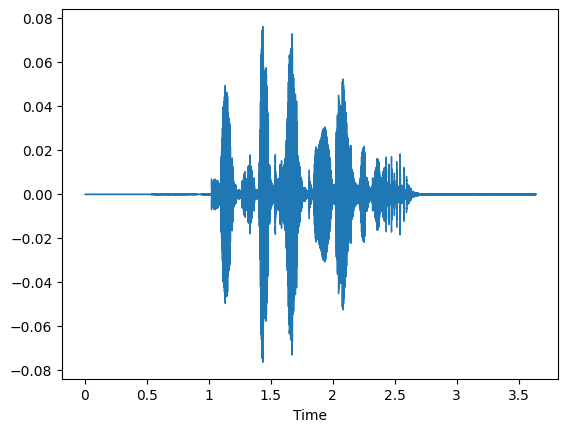

In [ ]:
data,rate=librosa.load(path+'/Actor_02/03-01-01-01-01-01-02.wav')
librosa.display.waveshow(data,sr=rate)
ipd.Audio(path+'/Actor_02/03-01-01-01-01-01-02.wav')

In [ ]:
file_path=[]
label=[]


for i in range(1,25):
  if i<10:
    root=path+'/Actor_0'
  else:
    root=path+'/Actor_'
  files=os.listdir(root+str(i))
  for j in files:
    file_path.append(root+str(i)+'/'+j)
    label.append(j.split('-')[2])


In [ ]:
df=pd.DataFrame()
df['file_path']=file_path
df['label']=label
df['label'] = df['label'].astype(int)
df.head()

,file_path,label
0,/kaggle/input/ravdess-emotional-speech-audio/A...,2
1,/kaggle/input/ravdess-emotional-speech-audio/A...,1
2,/kaggle/input/ravdess-emotional-speech-audio/A...,4
3,/kaggle/input/ravdess-emotional-speech-audio/A...,2
4,/kaggle/input/ravdess-emotional-speech-audio/A...,2


In [ ]:
def extract_features(file, max_len=200):

    audio, sr = librosa.load(file, sr=22050)

    mel = librosa.feature.melspectrogram(
        y=audio,
        sr=sr,
        n_mels=128
    )

    mel = librosa.power_to_db(mel)

    if mel.shape[1] < max_len:
        pad_width = max_len - mel.shape[1]
        mel = np.pad(mel, ((0,0),(0,pad_width)), mode='constant')
    else:
        mel = mel[:, :max_len]

    return mel

In [ ]:
features = []

for path in tqdm(df['file_path']):
    data = extract_features(path)
    features.append(data)

x = np.array(features)
y = df['label'].astype(int) - 1

100%|██████████| 1440/1440 [00:47<00:00, 30.48it/s]


In [ ]:
features_df = pd.DataFrame()
features_df['features'] = [feature for feature in x]
features_df['emotion_label'] = y.apply(lambda val: label_dict[val + 1])
print(features_df.head())

                                            features emotion_label
0  [[-73.06093, -69.93649, -78.4942, -78.59403, -...          calm
1  [[-76.45046, -76.45046, -76.45046, -76.45046, ...       neutral
2  [[-70.58771, -70.58771, -70.58771, -70.58771, ...           sad
3  [[-58.172836, -59.328648, -66.067154, -60.9024...          calm
4  [[-78.84561, -78.17843, -77.040016, -78.84561,...          calm


In [ ]:
import pickle

with open("features.pkl", "wb") as f:
    pickle.dump(features_df, f)

In [ ]:
x.shape

(1440, 128, 200)

In [ ]:
from sklearn.model_selection import train_test_split

x_train, x_test, y_train, y_test = train_test_split(
    x, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

In [ ]:
x_train.shape

(1152, 128, 200)

In [ ]:
x_train = x_train[..., np.newaxis]
x_test = x_test[..., np.newaxis]

In [ ]:
x_train.shape

(1152, 128, 200, 1)

In [ ]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout,Conv2D,MaxPooling2D,GlobalAveragePooling2D

model = Sequential()

model.add(Conv2D(32,(3,3),activation='relu',input_shape=(128,200,1)))
model.add(MaxPooling2D((2,2)))

model.add(Conv2D(64,(3,3),activation='relu'))
model.add(MaxPooling2D((2,2)))

model.add(Conv2D(128,(3,3),activation='relu'))
model.add(MaxPooling2D((2,2)))

model.add(GlobalAveragePooling2D())

model.add(Dense(128,activation='relu'))
model.add(Dropout(0.4))

model.add(Dense(8,activation='softmax'))

model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [ ]:
from sklearn.utils.class_weight import compute_class_weight
import numpy as np

class_weights = compute_class_weight(
    class_weight='balanced',
    classes=np.unique(y_train),
    y=y_train
)

class_weights = dict(enumerate(class_weights))

In [ ]:
from tensorflow.keras.callbacks import EarlyStopping
early_stopping = EarlyStopping(monitor='val_loss', patience=5, restore_best_weights=True)

history = model.fit(
    x_train,
    y_train,
    validation_data=(x_test, y_test),
    epochs=50,
    batch_size=32,
    class_weight=class_weights
)

Epoch 1/50
36/36 ━━━━━━━━━━━━━━━━━━━━ 9s 72ms/step - accuracy: 0.1406 - loss: 2.8513 - val_accuracy: 0.2639 - val_loss: 1.8885
Epoch 2/50
36/36 ━━━━━━━━━━━━━━━━━━━━ 1s 28ms/step - accuracy: 0.2326 - loss: 1.8730 - val_accuracy: 0.2917 - val_loss: 1.8394
Epoch 3/50
36/36 ━━━━━━━━━━━━━━━━━━━━ 1s 29ms/step - accuracy: 0.2611 - loss: 1.8148 - val_accuracy: 0.2604 - val_loss: 1.8534
Epoch 4/50
36/36 ━━━━━━━━━━━━━━━━━━━━ 1s 28ms/step - accuracy: 0.2275 - loss: 1.8530 - val_accuracy: 0.2812 - val_loss: 1.7996
Epoch 5/50
36/36 ━━━━━━━━━━━━━━━━━━━━ 1s 28ms/step - accuracy: 0.2609 - loss: 1.7935 - val_accuracy: 0.3056 - val_loss: 1.7813
Epoch 6/50
36/36 ━━━━━━━━━━━━━━━━━━━━ 1s 28ms/step - accuracy: 0.2458 - loss: 1.8277 - val_accuracy: 0.3160 - val_loss: 1.7093
Epoch 7/50
36/36 ━━━━━━━━━━━━━━━━━━━━ 1s 29ms/step - accuracy: 0.2653 - loss: 1.7847 - val_accuracy: 0.3611 - val_loss: 1.7232
Epoch 8/50
36/36 ━━━━━━━━━━━━━━━━━━━━ 1s 28ms/step - accuracy: 0.3077 - loss: 1.7714 - val_accuracy: 0.3368 - v

In [ ]:
loss, acc = model.evaluate(x_test, y_test)

print("Test Accuracy:", acc)

9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - accuracy: 0.5584 - loss: 1.1924
Test Accuracy: 0.5590277910232544


In [ ]:
model.save('ravdees.keras')

In [ ]:
model.save('ravdees.h5')